In [ ]:
from pathlib import Path
from functools import partial
from typing import Optional, Dict, List, Tuple
import datetime
import time

from rapidfuzz.distance import Levenshtein
import cv2

import jax
from jax import numpy as jnp
import flax
from flax import linen as nn
import optax
import orbax
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
from einops import rearrange, einsum

import albumentations as A

from matplotlib import pyplot as plt

key = jax.random.key(0)

In [163]:
class RoPE(nn.Module):
    hidden_dim: int
    theta_base: float = 10000

    @nn.compact
    def __call__(self, x: jnp.ndarray, input_ids: jnp.ndarray) -> jnp.ndarray:
        d = self.hidden_dim
        assert d % 2 == 0

        i = jnp.arange(0, d // 2)
        theta = self.theta_base ** (-2 * i / d)
        positions = input_ids[:, None, :, None]
        angles = positions * theta[None, None, None, :]

        cos = jnp.cos(angles)
        sin = jnp.sin(angles)
        x_pairs = rearrange(x, "b h n (d two) -> b h n d two", two=2)

        x_rotated = jnp.stack([x_pairs[..., 0] * cos - x_pairs[..., 1] * sin, x_pairs[..., 0] * sin + x_pairs[..., 1] * cos], axis=-1)
        x_rotated = rearrange(x_rotated, "b h n d two -> b h n (d two)")

        return x_rotated


class MultiHeadAttention(nn.Module):
    hidden_dim: int
    num_heads: int
    dropout: float = 0.0
    use_rope: bool = False

    @nn.compact
    def __call__(
        self,
        q: jnp.ndarray,
        k: jnp.ndarray,
        v: jnp.ndarray,
        input_ids: Optional[jnp.ndarray] = None,
        deterministic: bool = False,
        causal: bool = False,
        use_cache: bool = False,
    ) -> jnp.ndarray:
        q = nn.Dense(self.hidden_dim)(q)
        k = nn.Dense(self.hidden_dim)(k)
        v = nn.Dense(self.hidden_dim)(v)

        q = rearrange(q, "b n (h d) -> b h n d", h=self.num_heads)
        k = rearrange(k, "b n (h d) -> b h n d", h=self.num_heads)
        v = rearrange(v, "b n (h d) -> b h n d", h=self.num_heads)

        head_dim = self.hidden_dim // self.num_heads
        if self.use_rope:
            assert input_ids is not None
            rope = RoPE(hidden_dim=head_dim)
            q = rope(q, input_ids)
            k = rope(k, input_ids)

        if use_cache:
            assert self.is_mutable_collection("kv_cache")
            k_cache = self.variables["kv_cache"].get("k", None)
            v_cache = self.variables["kv_cache"].get("v", None)
            if k_cache is not None:
                k = jnp.concatenate([k_cache, k], axis=2)
                v = jnp.concatenate([v_cache, v], axis=2)

            self.put_variable("kv_cache", "k", k)
            self.put_variable("kv_cache", "v", v)

        attn_weights = einsum(q, k, "b h i d, b h j d -> b h i j") / jnp.sqrt(self.hidden_dim)
        if causal:
            i, j = attn_weights.shape[-2:]
            mask = jnp.triu(jnp.ones((i, j), dtype=jnp.bool), k=j - i + 1)[None, None, :, :]
            attn_weights = jnp.where(mask, jnp.finfo(attn_weights.dtype).min, attn_weights)
        attn_weights = jax.nn.softmax(attn_weights, axis=-1)
        attn_weights = nn.Dropout(rate=self.dropout)(attn_weights, deterministic=deterministic)

        out = einsum(attn_weights, v, "b h i j, b h j d -> b h i d")
        out = rearrange(out, "b h n d -> b n (h d)")

        return out


class SelfAttentionBlock(nn.Module):
    hidden_dim: int
    num_heads: int
    dropout: float = 0.0
    ffn_scale: float = 2.0
    use_rope: bool = False

    @nn.compact
    def __call__(
        self, x: jnp.ndarray, input_ids: jnp.ndarray, deterministic: bool = False, causal: bool = False, use_cache: bool = False
    ) -> jnp.ndarray:
        x_normed = nn.LayerNorm()(x)
        x = (
            MultiHeadAttention(self.hidden_dim, self.num_heads, self.dropout, use_rope=self.use_rope)(
                q=x_normed,
                k=x_normed,
                v=x_normed,
                input_ids=input_ids,
                deterministic=deterministic,
                causal=causal,
                use_cache=use_cache,
            )
            + x
        )
        return nn.Sequential([nn.Dense(int(self.hidden_dim * self.ffn_scale)), nn.gelu, nn.Dense(self.hidden_dim)])(nn.LayerNorm()(x)) + x


class CrossAttentionBlock(nn.Module):
    hidden_dim: int
    num_heads: int
    dropout: float = 0.0
    ffn_scale: float = 2.0

    @nn.compact
    def __call__(self, x: jnp.ndarray, c: jnp.ndarray, deterministic: bool = False) -> jnp.ndarray:
        x_normed = nn.LayerNorm()(x)
        c_normed = nn.LayerNorm()(c)
        x = (
            MultiHeadAttention(self.hidden_dim, self.num_heads, self.dropout, use_rope=False)(
                q=x_normed,
                k=c_normed,
                v=c_normed,
                deterministic=deterministic,
            )
            + x
        )
        return nn.Sequential([nn.Dense(int(self.hidden_dim * self.ffn_scale)), nn.gelu, nn.Dense(self.hidden_dim)])(nn.LayerNorm()(x)) + x


class ViTEncoder(nn.Module):
    patch_size: int
    num_layers: int
    hidden_dim: int
    num_heads: int
    dropout: float = 0.0
    ffn_scale: float = 2.0
    add_cls_token: bool = True
    use_rope: bool = False

    @nn.compact
    def __call__(self, img: jnp.ndarray, deterministic: bool = False) -> jnp.ndarray:
        b, *_ = img.shape

        x = rearrange(img, "b c h w -> b h w c")
        x = nn.Conv(
            features=self.hidden_dim,
            kernel_size=(self.patch_size, self.patch_size),
            strides=(self.patch_size, self.patch_size),
            padding="VALID",
        )(x)
        x = rearrange(x, "b hp wp d -> b (hp wp) d")

        if self.add_cls_token:
            cls_token = self.param(
                "cls_token",
                nn.initializers.zeros,
                (1, 1, self.hidden_dim),
            )
            cls_token = jnp.broadcast_to(cls_token, (b, 1, self.hidden_dim))
            x = jnp.concatenate([cls_token, x], axis=1)

        seq_len = x.shape[1]
        input_ids = jnp.broadcast_to(jnp.arange(0, seq_len)[None, :], (b, seq_len))

        for _ in range(self.num_layers):
            x = SelfAttentionBlock(
                hidden_dim=self.hidden_dim,
                num_heads=self.num_heads,
                dropout=self.dropout,
                ffn_scale=self.ffn_scale,
                use_rope=self.use_rope,
            )(x=x, input_ids=input_ids, deterministic=deterministic)

        x = nn.LayerNorm()(x)
        return x


class AutoregressiveTransformerDecoder(nn.Module):
    vocab_size: int
    num_layers: int
    hidden_dim: int
    num_heads: int
    dropout: float = 0.0
    ffn_scale: float = 2.0
    use_rope: bool = False

    @nn.compact
    def __call__(self, x: jnp.ndarray, c: jnp.ndarray, input_ids: jnp.ndarray, deterministic: bool = False, use_cache: bool = False) -> jnp.ndarray:
        x = nn.Embed(self.vocab_size + 1, self.hidden_dim)(x)
        for _ in range(self.num_layers):
            x = SelfAttentionBlock(
                hidden_dim=self.hidden_dim,
                num_heads=self.num_heads,
                dropout=self.dropout,
                ffn_scale=self.ffn_scale,
                use_rope=self.use_rope,
            )(x=x, input_ids=input_ids, deterministic=deterministic, causal=True, use_cache=use_cache)
            x = CrossAttentionBlock(
                hidden_dim=self.hidden_dim,
                num_heads=self.num_heads,
                dropout=self.dropout,
                ffn_scale=self.ffn_scale,
            )(x=x, c=c, deterministic=deterministic)

        logits = nn.Dense(self.vocab_size)(x)
        return logits


In [164]:
encoder = ViTEncoder(patch_size=16, num_layers=2, hidden_dim=128, num_heads=4, dropout=0.1, ffn_scale=4.0, use_rope=True)
dummy_input = jnp.zeros((1, 3, 56, 280), dtype=jnp.float32)
key, subkey = jax.random.split(key)
params = encoder.init(subkey, dummy_input)

ctx = encoder.apply(params, dummy_input, deterministic=True)
print(f"ctx shape: {ctx.shape}")

decoder = AutoregressiveTransformerDecoder(vocab_size=7, num_layers=2, hidden_dim=128, num_heads=4, dropout=0.1, ffn_scale=4.0, use_rope=True)
dummy_x = jnp.zeros((1, 10), dtype=jnp.int32)
input_ids = jnp.arange(0, dummy_x.shape[1])[None, :].repeat(1, axis=0)
key, subkey = jax.random.split(key)
params = decoder.init(subkey, dummy_x, ctx, input_ids)

out = decoder.apply(params, dummy_x, ctx, input_ids, deterministic=True)
print(f"out shape: {out.shape}")

ctx shape: (1, 52, 128)
out shape: (1, 10, 7)


In [224]:
class OCRDataset(Dataset):
    def __init__(
        self,
        root_dir: str,
        has_labels: bool,
        transform: Optional[A.Compose],
        vocab_dict: Dict[str, int],
        max_length: int,
    ):
        self.root_dir = Path(root_dir)
        self.has_labels = has_labels
        self.transform = transform
        self.image_paths = list(self.root_dir.glob("**/*.png"))
        self.vocab_dict = vocab_dict
        self.max_length = max_length
        if has_labels:
            self.labels = list(
                map(lambda x: list(map(lambda char: vocab_dict[char], x.stem.split("_")[-1])), self.image_paths)
            )
            assert all(map(lambda x: len(x) <= max_length, self.labels)), "Label length exceeds max length"
        else:
            self.labels = [None] * len(self.image_paths)

    def set_transform(self, transform: Optional[A.Compose]):
        self.transform = transform

    def train_test_split(self, subkey: jax.random.key, test_size: float = 0.2):
        indices = jax.random.permutation(subkey, len(self.image_paths))
        test_indices = indices[: int(len(indices) * test_size)]
        train_indices = indices[int(len(indices) * test_size) :]

        train_dataset = OCRDataset(
            root_dir=self.root_dir,
            has_labels=self.has_labels,
            transform=self.transform,
            vocab_dict=self.vocab_dict,
            max_length=self.max_length,
        )
        test_dataset = OCRDataset(
            root_dir=self.root_dir,
            has_labels=self.has_labels,
            transform=self.transform,
            vocab_dict=self.vocab_dict,
            max_length=self.max_length,
        )
        train_dataset.image_paths = [self.image_paths[i] for i in train_indices]
        train_dataset.labels = [self.labels[i] for i in train_indices]
        test_dataset.image_paths = [self.image_paths[i] for i in test_indices]
        test_dataset.labels = [self.labels[i] for i in test_indices]

        return train_dataset, test_dataset

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        image_path = self.image_paths[idx]
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
        if self.transform:
            image = jnp.array(self.transform(image=image)["image"], dtype=jnp.float32)
        else:
            image = jnp.array(image, dtype=jnp.float32) / 255.0


        image = image.transpose(2, 0, 1)

        return image, self.labels[idx]


def collate_fn(
    batch: List[Tuple[jnp.ndarray, List[int]]], max_length: int
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    images = []
    labels = []
    lengths = []
    for image, label in batch:
        images.append(image)
        length = 0
        if label is not None:
            length = len(label)

            label = label + [-1] * (max_length - length)
        labels.append(label)
        lengths.append(length)

    images = jnp.stack(images)

    if labels[0] is not None:
        labels = jnp.array(labels, dtype=jnp.int32)
        lengths = jnp.array(lengths, dtype=jnp.int32)
    
    return images, labels, lengths


def get_vocab(root_dir: str) -> Dict[str, int]:
    vocab = set()
    for path in Path(root_dir).glob("**/*.png"):
        vocab.update(path.stem.split("_")[-1])
    vocab_list = ["<blank>", "<unk>"] + sorted(list(vocab))
    vocab_dict = {char: i for i, char in enumerate(vocab_list)}
    return vocab_dict


def distance(pred: jnp.ndarray, target: jnp.ndarray) -> int:
    assert pred.ndim == 1 and target.ndim == 1
    return Levenshtein.distance(pred[pred != -1].tolist(), target[target != -1].tolist())


max_length = 16
size = (56, 280)
mean = (0.5, 0.5, 0.5)
std = (0.5, 0.5, 0.5)

train_transform = A.Compose(
    [
        A.Resize(*size, interpolation=cv2.INTER_AREA),
        A.OneOf(
            [
                A.MotionBlur(blur_limit=5),
                A.GaussianBlur(blur_limit=(3, 5)),
                A.MedianBlur(blur_limit=3),
            ],
            p=0.3,
        ),
        A.Perspective(scale=(0.02, 0.05), keep_size=True, p=0.2),
        A.OneOf(
            [
                A.ColorJitter(0.2, 0.2, 0.2, 0.1),
                A.RandomBrightnessContrast(0.2, 0.2),
                A.CLAHE(clip_limit=2.0),
            ],
            p=0.6,
        ),
        A.OneOf(
            [
                A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5)),
                A.MultiplicativeNoise(multiplier=(0.9, 1.1), per_channel=True),
            ],
            p=0.3,
        ),
        A.ImageCompression(quality_range=(60, 95), p=0.2),
        A.Normalize(mean=mean, std=std),
    ]
)

val_transform = A.Compose(
    [
        A.Resize(*size, interpolation=cv2.INTER_AREA),
        A.Normalize(mean=mean, std=std),
    ]
)

In [225]:
num_epochs = 50
lr = 1e-3
vocab_dict = get_vocab("data/train")
dataset = OCRDataset(root_dir="data/train", has_labels=True, transform=None, vocab_dict=vocab_dict, max_length=max_length)

key, subkey = jax.random.split(key)
train_dataset, val_dataset = dataset.train_test_split(subkey)
train_dataset.set_transform(train_transform)
val_dataset.set_transform(val_transform)

test_dataset = OCRDataset(root_dir="data/test", has_labels=False, transform=val_transform, vocab_dict=vocab_dict, max_length=max_length)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, collate_fn=partial(collate_fn, max_length=max_length), pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, collate_fn=partial(collate_fn, max_length=max_length), pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, collate_fn=partial(collate_fn, max_length=max_length), pin_memory=True)


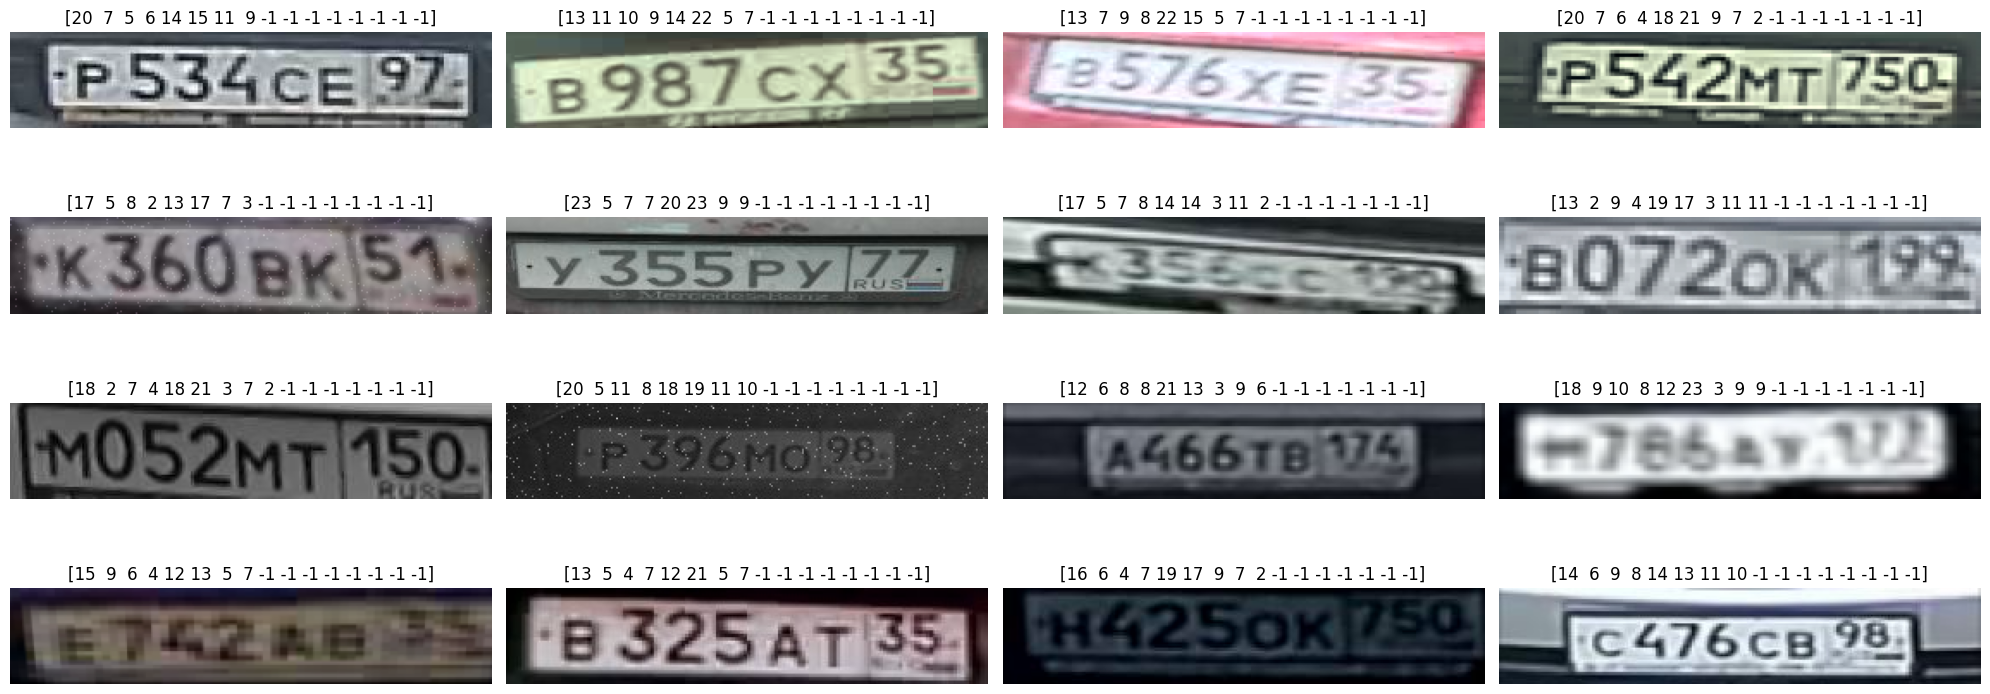

In [229]:
batch = next(iter(train_loader))
images_set = []
labels_set = []
should_break = False
for images, labels, _ in train_loader:
    for image, label in zip(images, labels):
        images_set.append(image)
        labels_set.append(label)
        if len(images_set) >= 16:
            should_break = True
            break
    if should_break:
        break

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    image, label = images_set[i], labels_set[i]
    ax.imshow(image.transpose(1, 2, 0) / 2 + 0.5)
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()

729479

In [6]:
def train(
    model: OCR,
    optimizer: optim.Optimizer,
    scheduler: optim.lr_scheduler.LRScheduler,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: str,
    num_epochs: int,
    experiment_name: str,
    log_dir: str = "logs",
):
    experiment_name = f"{experiment_name}-{datetime.datetime.now().strftime('%Y-%m-%d-%H-%M-%S')}"
    log_dir = f"{log_dir}/{experiment_name}"
    writer = SummaryWriter(log_dir=log_dir)
    model = model.to(device)
    global_step = 0
    min_distance = float("inf")

    for epoch in range(num_epochs):
        model.train()
        for images, labels, lengths in train_loader:
            start_time = time.time()
            images = images.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device)
            optimizer.zero_grad()
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits = model(images)
                loss = model.loss_fn(logits, labels, lengths)
            loss.backward()
            optimizer.step()
            scheduler.step()
            preds = model.get_predicted_sequence(logits.detach())
            distances = list(map(lambda pred, target: distance(pred, target), preds, labels))
            end_time = time.time()
            lr = optimizer.param_groups[0]["lr"]
            writer.add_scalar("train/loss", loss.item(), global_step)
            writer.add_scalar("train/lr", lr, global_step)
            writer.add_scalar("train/batch_time", end_time - start_time, global_step)
            writer.add_scalar("train/distance", sum(distances) / len(distances), global_step)
            global_step += 1

        model.eval()
        sum_losses = 0.0
        sum_distances = 0.0
        num_samples = 0.0
        with torch.no_grad():
            for images, labels, lengths in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                lengths = lengths.to(device)
                logits = model(images)
                preds = model.get_predicted_sequence(logits)
                losses = list(
                    map(
                        lambda logits_, label, length: model.loss_fn(logits_[None], label[None], length[None]),
                        logits,
                        labels,
                        lengths,
                    )
                )
                distances = list(map(lambda pred, target: distance(pred, target), preds, labels))
                sum_losses += sum(losses)
                sum_distances += sum(distances)
                num_samples += len(losses)
        avg_loss = sum_losses / num_samples
        avg_distance = sum_distances / num_samples
        writer.add_scalar("val/loss", avg_loss, epoch)
        writer.add_scalar("val/distance", avg_distance, epoch)
        if avg_distance < min_distance:
            min_distance = avg_distance
            torch.save(model.state_dict(), f"{log_dir}/checkpoint.pth")
    

In [7]:
# train(model, optimizer, scheduler, train_loader, val_loader, device, num_epochs, experiment_name="pretraned_backbone_long_train")

In [8]:
class STN(nn.Module):
    def __init__(self):
        super(STN, self).__init__()

        self.localization = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2, bias=True),
            nn.MaxPool2d(2, stride=2),
            nn.PReLU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=2, bias=True),
            nn.MaxPool2d(2, stride=2),
            nn.PReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=2, bias=True),
            nn.MaxPool2d(2, stride=2),
            nn.PReLU(),
        )


        self.fc_loc = nn.Sequential(
            nn.Linear(64 * 8 * 36, 64, bias=True), nn.PReLU(), nn.Linear(64, 3 * 2, bias=True)
        )

        self.fc_loc[2].weight.data.zero_()
        self.fc_loc[2].bias.data.copy_(torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float))

    def forward(self, x):
        xs = self.localization(x)
        xs = xs.view(-1, 64 * 8 * 36)

        theta = self.fc_loc(xs)
        theta = theta.view(-1, 2, 3)

        grid = F.affine_grid(theta, x.size(), align_corners=True)
        x = F.grid_sample(x, grid, align_corners=True)
        return x

class OCRCTN(nn.Module):
    def __init__(self, stn: STN, ocr: OCR):
        super().__init__()
        self.stn = stn
        self.ocr = ocr

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stn(x)
        return self.ocr(x)
    
    def get_predicted_sequence(self, logits: torch.Tensor, blank: int = 0) -> torch.LongTensor:
        return self.ocr.get_predicted_sequence(logits, blank)
    
    def predict(self, x: torch.Tensor, blank: int = 0) -> torch.LongTensor:
        x = self.stn(x)
        return self.ocr.predict(x, blank)
    
    def loss_fn(self, logits: torch.Tensor, labels: torch.LongTensor, lengths: torch.LongTensor) -> torch.Tensor:
        return self.ocr.loss_fn(logits, labels, lengths)
    

In [18]:
num_epochs = 20
lr = 1e-4
model = OCR(num_classes=len(vocab_dict))
model.load_state_dict(torch.load("logs/pretraned_backbone_long_train-2025-11-23-11-13-16/checkpoint.pth", map_location="cpu", weights_only=False), strict=True)
model = model.to(device)
stn = STN()
model_stn = OCRCTN(stn, model)
params = [
    {"params": model_stn.ocr.parameters(), "lr": lr * 1e-4},
    {"params": model_stn.stn.parameters(), "lr": lr},
]
optimizer = optim.AdamW(params, lr=lr)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, total_steps=num_epochs * len(train_loader), cycle_momentum=False)

In [19]:
train(model_stn, optimizer, scheduler, train_loader, val_loader, device, num_epochs, experiment_name="stn")

In [23]:
model_stn.load_state_dict(torch.load("logs/stn-2025-11-23-12-10-36/checkpoint.pth", map_location="cpu", weights_only=False), strict=True)
model_stn = model_stn.to(device).eval()

In [24]:
inverse_vocab_dict = {v: k for k, v in vocab_dict.items()}

preds = []
with torch.no_grad():
    for images, *_ in test_loader:
        images = images.to(device)
        pred = model_stn.predict(images).numpy(force=True).tolist()
        for p in pred:
            preds.append("".join(list(map(lambda x: inverse_vocab_dict.get(x, ""), p))))
        


In [25]:
import pandas as pd
assert len(preds) == len(test_loader.dataset.image_paths)
result = [{"index": path.stem, "label": pred} for path, pred in zip(test_loader.dataset.image_paths, preds)]

result = pd.DataFrame(result)
result.to_csv("result.csv", index=False)


# Результаты экспериментов

| Эксперимент | Описание | Эпохи | val/loss | val/distance |
|-------------|----------|-------|------|-------------|
| baseline | Энкодер из семинара, декодер из одного слоя GRU и линейная проекция на логиты | 20 | 0.05292 | 0.0701 |
| augmentations | Добавление аугментаций в тренировочный датасет | 20 | 0.0367 | 0.0645 |
| pretrained_backbone | Использование предобученного ResNet18 в качестве бэкбона | 20 | 0.026 | 0.0361 |
| scale_up | Увеличение количества GRU слоёв до 3 | 20 | 0.0308 | 0.0394 |
| attention | Замена GRU на SelfAttention, *0.5 batch_size | 20 | 0.0328 | 0.0442 |
| pretrained_backbone_long_train | Лучший эксперимент с 50 epochs и *0.5 batch_size (ищем flat minima) | 50 | 0.0244 | 0.0312 |
| stn | Добавление STN в готовую модель, lr предобученной модели *1e-4 | 20 | 0.0143 | 0.0212 |

**Лучший эксперимент:** pretrained_backbone $\rightarrow$ pretrained_backbone_long_train $\rightarrow$ stn